## STOCHASTIC MODELING
MODULE 6 | LESSON 2


---



# **Reinforcement Learning: The Gridworld**

|  |  |
|:---|:---|
|**Reading Time** |  45 minutes |
|**Prior Knowledge** | MDP, Policy iteration |
|**Keywords** | Gridworld, Optimal policy


---

In the last lesson, we solved a tiny MDP with just three states—great to get familiar with all the tools, such as Bellman equations. The Gridworld scales that intuition into a small “mini-universe” where we will deal with iterative policy evaluation when matrices get bigger, and watch policies improvement to its full extent.

In [1]:
# Import libraries to be used later on
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## **1. The Gridworld**



In [2]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1129186337", h="3298dbabb7", width=700, height=450) 

Let's construct our Gridworld universe. To begin with, we are going to start with a classic 4 x 4 grid, where each square (or cell) corresponds to a state. There are 2 terminal cells in the grid (upper left and bottom right cells), that are. either, the goal of the agent. The agent 'randomly' appears in one cell of the Gridworld and has to take actions to reach a terminal cell in the lowest amount of steps possible. For this example, the agent can move up, down, left or right, and each movement implies a negative reward of $-1$, to reflect that we would like to minimize the agent's effort. In other words, we want the agent to learn to reach a terminal cell in the minimum number of steps possible.

So, first, let's draw our Gridworld with code. Note that the following code is simply for illustrative purposes of the grid:

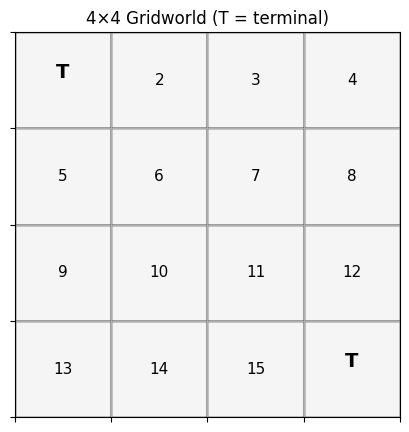

In [3]:
H, W = 4, 4
terminals = {1: 0.0, 16: 1.0}   # example: cell 1 (top-left) and cell 16 (bottom-right) are terminals
show_terminal_numbers = False   # set True if you also want to print the number under the T
walls = set() # In case we want to place walls somewhere

def rc_to_id(r, c, W=W):
    """Row-major numbering (top row = 1..W, next row = W+1..2W, etc.)."""
    return r * W + c + 1

def id_to_rc(cell_id, W=W):
    cell_id -= 1
    return divmod(cell_id, W)  # (r, c)

def draw_gridworld_numbered(H=H, W=W, terminals=terminals, walls=walls):
    fig, ax = plt.subplots(figsize=(5, 5))
    for r in range(H):
        for c in range(W):
            cell_id = rc_to_id(r, c, W)
            # draw cell
            face = '#f5f5f5' if cell_id not in walls else '#444444'
            rect = Rectangle((c, H-1-r), 1, 1, fill=True, edgecolor='black', facecolor=face)
            ax.add_patch(rect)

            # label
            if cell_id in walls:
                ax.text(c+0.5, H-1-r+0.5, "WALL", ha='center', va='center', color='white', fontsize=9)
            elif cell_id in terminals:
                ax.text(c+0.5, H-1-r+0.58, "T", ha='center', va='center', fontsize=14, fontweight='bold')
                if show_terminal_numbers:
                    ax.text(c+0.5, H-1-r+0.25, f"{cell_id}", ha='center', va='center', fontsize=9)
            else:
                ax.text(c+0.5, H-1-r+0.5, f"{cell_id}", ha='center', va='center', fontsize=11)

    # axes cosmetics
    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(range(W+1)); ax.set_yticks(range(H+1))
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, which='both')
    ax.set_aspect('equal')
    ax.set_title("4×4 Gridworld (T = terminal)")
    plt.show()

draw_gridworld_numbered()


### 1.1. Defininig agent's actions and dynamics

In this 4 x 4 Gridworld, the agent can take a number of costly actions, with the aim of ending as quickly as possible in one of the terminal cells. The agent also has some *patience* that controls how much future rewards matter. Here, we will set $\gamma = 0.95$ for illustrative purposes. Intuitively, a higher value of gamma will make the agent more prone to take detours, while lower values discourage wandering. Of course, some wandering is necessary to reach the terminal cells, so we'd like to balance these effects.

In [4]:
# Define the Gridworld universe
H, W = 4, 4
cells = list(range(1, H*W + 1))
terminals = {1: 0.0, 16: 1.0}
walls = set()     # In case we wanted to set some walls in the grid
step_cost = -1.0
gamma = 0.95


# Define agent's actions and states
actions = ['U','R','D','L']
A = len(actions)
S = len(cells)
a2i = {a:i for i,a in enumerate(actions)}

# Define what movements actions imply
delta = {'U':(-1,0), 'R':(0,1), 'D':(1,0), 'L':(0,-1)}


# Define some functions to map row-column pairs to cells in the grid (and vice versa)
def rc_to_id(r, c, W=W):
    return r*W + c + 1

def id_to_rc(cell_id, W=W):
    cell_id -= 1
    return divmod(cell_id, W)


# This helper function simply checks that we are not moving outside the grid
def in_bounds(r, c):
    return 0 <= r < H and 0 <= c < W and (rc_to_id(r,c) not in walls)


# Calculate transition probabilities and rewards
P = np.zeros((A, S, S))
r = np.zeros((A, S))

for s in cells:
    s_idx = s - 1
    r0, c0 = id_to_rc(s)
    is_terminal = (s in terminals)
    for a in actions:
        ai = a2i[a]
        if is_terminal:
            P[ai, s_idx, s_idx] = 1.0
            r[ai, s_idx] = 0.0
            continue
        dr, dc = delta[a]
        r1, c1 = r0 + dr, c0 + dc
        if not in_bounds(r1, c1):     # check whether we are in bounds of the grid!
            s_next = s
        else:
            s_next = rc_to_id(r1, c1)

        s_next_idx = s_next - 1
        P[ai, s_idx, s_next_idx] = 1.0

        # Reward = step cost (each move counts) + terminal bonus if entering a terminal
        # In baseline, rewards are -1 to all cells except in the terminals.
        rew = step_cost + (terminals[s_next] if s_next in terminals else 0.0)
        r[ai, s_idx] = rew

### 1.2. Policy evaluation step

Now that we have defined our universe, we would like that the agent learns about how their actions affect the expected goal. For that, we first need a **policy evaluation** function. In the same spirit as our simple investment MDP from Lesson 1, we will rely on Bellman equations.

First, we will build a function to calculate $P_\pi$ and $R_\pi$, the transition probabilities and rewards under a certain policy $\pi$. This will facilitate the policy evaluation process later on:

In [5]:
def build_policy(policy, P, r, terminals, actions, a2i, S):
    P_pi = np.zeros((S, S))
    r_pi = np.zeros(S)
    for s in range(1, S+1):
        si = s - 1
        if s in terminals:
            P_pi[si, si] = 1.0
            r_pi[si] = 0.0
        else:
            ai = a2i[policy[si]]
            P_pi[si] = P[ai, si]
            r_pi[si] = r[ai, si]
    return P_pi, r_pi

Now, its time for the policy evaluation function. Here, we can opt for 2 different choices. One, is our "classic" policy evaluation function from the previous lesson, which directly solves for the V-function. This is a good choice for when we have a deterministic policy that can be solved linearly:

In [6]:
def policy_eval_linear(policy, P, r, terminals, actions, a2i, gamma=gamma):
    S = r.shape[1]
    P_pi, r_pi = build_policy(policy, P, r, terminals, actions, a2i, S)
    V = np.linalg.solve(np.eye(S) - gamma * P_pi, r_pi)
    return V

However, as we progress in the RL field, we would probably like to estimate using iterations this V-function. Doing this is extremely helpful when convergence is not guaranteed or there are non-linearities involved:

In [7]:
def policy_eval(policy, P, r, terminals, actions, a2i, gamma=gamma, tol=1e-10, max_iter=10000):
    S = r.shape[1]
    V = np.zeros(S)
    P_pi, r_pi = build_policy(policy, P, r, terminals, actions, a2i, S)
    for _ in range(max_iter):
        V_new = r_pi + gamma * (P_pi @ V)
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new
    return V


As we can check with the following example, there are not going to be huge differences when using either in simple problems. That's why we usually opt for the iterative one, avoiding potential problems related to linearity.

To check this, let's pick a simple initial policy: the agent will choose moving right in all cells (ignoring for now terminal ones since we are in evaluation):

In [8]:
policy = ['R'] * 16

V_iter = policy_eval(policy, P, r, terminals, actions, a2i, gamma=0.95)
print("V (iterative):")
print(np.round(V_iter.reshape(4,4), 2))

# Optional cross-check:
V_lin = policy_eval_linear(policy, P, r, terminals, actions, a2i, gamma=0.95)
print("V (linear):")
print(np.round(V_lin.reshape(4,4), 2))

print("Max abs diff (iter vs linear):", np.max(np.abs(V_iter - V_lin)))

V (iterative):
[[  0.   -20.   -20.   -20.  ]
 [-20.   -20.   -20.   -20.  ]
 [-20.   -20.   -20.   -20.  ]
 [ -1.95  -1.     0.     0.  ]]
V (linear):
[[  0.   -20.   -20.   -20.  ]
 [-20.   -20.   -20.   -20.  ]
 [-20.   -20.   -20.   -20.  ]
 [ -1.95  -1.     0.     0.  ]]
Max abs diff (iter vs linear): 1.8908288268448814e-09


### 1.3. Policy improvement step

Our next step is to define policy improvement. Following the example in Lesson 1, this first entails using Bellman equations to compute $Q^\pi$ from $V^\pi$:

In [9]:
def Q_function(V, P, r, gamma=gamma):
    """
    Q[s, a] = r[a, s] + gamma * sum_{s'} P[a, s, s'] * V[s']
    Shapes: P (A,S,S), r (A,S), V (S,)
    """
    A, S = r.shape[0], r.shape[1]
    Q = np.zeros((S, A))
    for ai in range(A):
        Q[:, ai] = r[ai] + gamma * (P[ai] @ V)
    return Q

Now we can focus on the policy improvement function. Apart from the traditional computations, we will incorporate a "tie-breaker" here, for the algorithm to choose among actions with equal $Q^\pi (s, a)$:

In [10]:
def policy_improv(V, P, r, actions, terminals, gamma=gamma, tie_break="first"):
    """
    Returns: new deterministic policy (list[str]) and a 'changed' flag.
    - Terminals keep a dummy action (e.g., 'T') and are ignored by evaluation.
    - tie_break: 'first' (default) or 'random' for argmax ties: break ties randomly.
    """
    Q = Q_function(V, P, r, gamma)
    S, A = Q.shape
    new_policy = []
    for s in range(1, S+1):
        si = s - 1
        if s in terminals:
            new_policy.append('T')
            continue
        if tie_break == "first":
            # Default tie-breaking
            ai = int(np.argmax(Q[si]))
        else:
            # Random tie-breaking (optional)
            best = np.where(Q[si] == Q[si].max())[0]
            ai = int(np.random.choice(best))
        new_policy.append(actions[ai])
    return new_policy

### 1.4. Optimal policy

Finally, we are ready to implement our simple RL algorithm and make our agents learnt their way towards terminal cells as quickly as possible!

Let's define a very simple initial policy of always moving right ('R') in every cell; and define cells 1st and 16th as terminal ones ('T'):

In [11]:
policy = ['R'] * 16
policy[0] = 'T'; policy[-1] = 'T'

converge = False; iter = 0
while not converge:
    iter += 1
    V = policy_eval(policy, P, r, terminals, actions, a2i, gamma=0.95)
    improved = policy_improv(V, P, r, actions, terminals, gamma=0.95)
    converge = (improved == policy)
    print(f"Iter {iter}: policy changed = {not converge}")
    policy = improved

print("Optimal policy:", policy)

Iter 1: policy changed = True
Iter 2: policy changed = True
Iter 3: policy changed = True
Iter 4: policy changed = False
Optimal policy: ['T', 'L', 'L', 'D', 'U', 'U', 'R', 'D', 'U', 'R', 'R', 'D', 'R', 'R', 'R', 'T']


Now we have obtained our optimal policy at each state (i.e., each cell). According to this optimal policy, when the agent is in cell 2, for instance, she will always choose to move left to quickly reach the terminal cell.

To better illustrate optimal policy, take a look at the following graph:

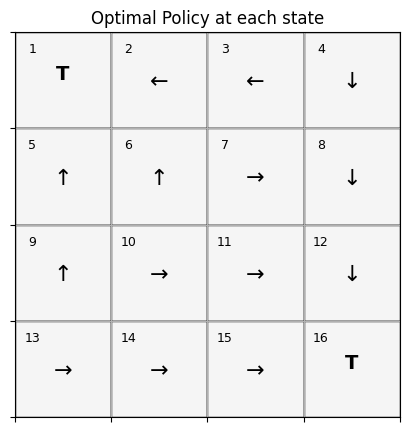

In [12]:
ARROW = {'U':'↑', 'R':'→', 'D':'↓', 'L':'←', 'T':'T'}

def draw_policy_grid(policy, H=4, W=4, terminals={1:0.0, 16:1.0}, walls=set()):
    assert len(policy) == H*W, "policy must have one action per cell (length H*W)."
    fig, ax = plt.subplots(figsize=(5, 5))

    for r in range(H):
        for c in range(W):
            cell_id = r*W + c + 1
            face = '#f5f5f5' if cell_id not in walls else '#444444'
            rect = Rectangle((c, H-1-r), 1, 1, fill=True, edgecolor='black', facecolor=face)
            ax.add_patch(rect)


            if cell_id not in walls:
                ax.text(c+0.18, H-1-r+0.82, f"{cell_id}", ha='center', va='center', fontsize=9, color='black')

            if cell_id in walls:
                ax.text(c+0.5, H-1-r+0.5, "WALL", ha='center', va='center', color='white', fontsize=9)
            elif cell_id in terminals:
                ax.text(c+0.5, H-1-r+0.56, "T", ha='center', va='center', fontsize=14, fontweight='bold')
            else:
                a = policy[cell_id-1]
                a = 'T' if a not in ('U','R','D','L') else a
                ax.text(c+0.5, H-1-r+0.48, ARROW[a], ha='center', va='center', fontsize=16)


    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_xticks(range(W+1)); ax.set_yticks(range(H+1))
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, which='both')
    ax.set_aspect('equal')
    ax.set_title("Optimal Policy at each state")
    plt.show()


draw_policy_grid(policy, H=4, W=4, terminals={1:0.0, 16:1.0}, walls=set())


Feel free to play around with these Gridworld example. You could alter rewards, costs of each step, or patience to see how this modifies the optimal policy of the agent. Moreover, we recommend you start by checking how changing the "tie-breaker" to random affects things, or how many iterations does the algorithm take to achive optimal policy if the initial policy is different.

## **2. The Windy Gridworld**

The Gridworld constitutes a very illustrative setting, but it is arguably quite simple. So let's complicate things a bit.

Suppose that the agent is now in a **"Windy Gridworld"**. The universe (grid) is the same we have been considering, but now transitions are stochastic because once the agent chooses and action in a given cell, a wind drift nudges her in some direction (e.g., 1 cell up) with some probability. This means that now shortest paths are not always the safest and our optimal policy needs to balance progress with the robustnees to the wind drift. This is definitely a much more interesting world!

In order to implement this Windy Gridworld, we essentially need to change the initial setup to incorporate the behavior of wind. We will assume that the wind is currently striking from the east, therefore moving the agent 1 cell to the left at each action. Also, the wind is not homogenously striking the Gridworld, but each 'column' of cells have a different probability of receiving wind such that, in columns left to right:

$$
p_w = [0.2, 0.4, 0.5, 0.2]
$$

Also, we will assume that when wind strikes while the agent is in wall (border), the agent will bounce. So, let's rebuild our setup consequently:

In [13]:
# P(wind strikes per column)
wind_col_p = np.array([0.2, 0.4, 0.5, 0.2])

# Movement left from wind
def left_of(cell_id):
    r0, c0 = id_to_rc(cell_id)
    c1 = c0 - 1
    if 0 <= c1 < W and rc_to_id(r0, c1) not in walls:
        return rc_to_id(r0, c1)   # valid left cell
    return cell_id                 # bounce (stay) if off-grid or wall

# Rebuild P and R with wind (action then wind)
P = np.zeros((A, S, S))
r = np.zeros((A, S))

for s in cells:
    si = s - 1
    r0, c0 = id_to_rc(s)
    if s in terminals:
        # Absorbing in terminals; no wind applied after arrival to 'T'
        for ai in range(A):
            P[ai, si, si] = 1.0
            r[ai, si] = 0.0
        continue

    for a in actions:
        ai = a2i[a]

        dr, dc = delta[a]
        r1, c1 = r0 + dr, c0 + dc
        s_a = s if not in_bounds(r1, c1) else rc_to_id(r1, c1)

        # If the action already lands in a terminal, treat it as terminal before wind (no wind after entry)
        if s_a in terminals:
            P[ai, si, s_a - 1] = 1.0
            r[ai, si] = step_cost + terminals[s_a]
            continue

        # Apply wind if not in terminal cell
        _, c_a = id_to_rc(s_a)
        p_w = float(wind_col_p[c_a])   # wind prob depends on column

        s_w = left_of(s_a)             # wind pushes left by one (or bounce)

        # Mixture of two possible next states: stay (no-wind) or left (wind)
        P[ai, si, s_a - 1] += (1.0 - p_w)
        P[ai, si, s_w - 1] += p_w

        # Expected reward = step cost + expected terminal bonus based on where you end up
        bonus_no_wind = terminals[s_a] if s_a in terminals else 0.0
        bonus_wind    = terminals[s_w] if s_w in terminals else 0.0
        r[ai, si] = step_cost + (1.0 - p_w) * bonus_no_wind + p_w * bonus_wind


With this new setup, and given we have defined all the needed functions before, we can proceed to solve for the optimal policy in the Windy Gridworld:

In [14]:
policy_w = ['R'] * 16
policy_w[0] = 'T'; policy_w[-1] = 'T'

converge = False; iter = 0
while not converge:
    iter += 1
    V = policy_eval(policy_w, P, r, terminals, actions, a2i, gamma=0.95)
    improved = policy_improv(V, P, r, actions, terminals, gamma=0.95)
    converge = (improved == policy_w)
    print(f"Iter {iter}: policy changed = {not converge}")
    policy_w = improved

print("Optimal policy:", policy_w)

Iter 1: policy changed = True
Iter 2: policy changed = True
Iter 3: policy changed = True
Iter 4: policy changed = False
Optimal policy: ['T', 'L', 'L', 'L', 'U', 'U', 'U', 'D', 'U', 'U', 'R', 'D', 'U', 'R', 'R', 'T']


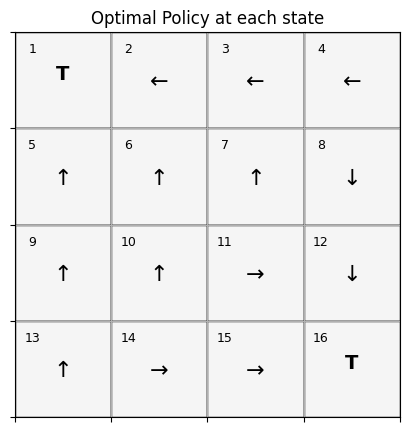

In [15]:
draw_policy_grid(policy_w, H=4, W=4, terminals={1:0.0, 16:1.0}, walls=set())


As you can see, there are some differences in the optimal policy with wind. For instance, when there was no wind, the optimal decision in cell 13 would be to move right or up with equal value. When we incorporate the probability of wind, even if low, there would be no point in choosing to move right, as if wind hits it would leave us in exactly the same position. A similar case can be made in cell 4.

## **3. Conclusion**

Well done! In this lesson we have taken one more step forward in learning how classic RL algorithms such as the Gridworld works. Notice that, most importantly, we need to learn about the different steps undertaken (policy evaluation, improvement, iteration,...). The math component between each of these is based on Bellman equations and relatively easy to gather, but they are still the foundation of way more complex models.

In the next two lessons we will take a look at more complex models in the context of investment and asset allocation.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
